# Topological Data Analysis (TDA) of Papp Permeability Dataset

This notebook performs feature engineering and topological data analysis on the curated Papp permeability dataset.

The workflow includes:
- Morgan fingerprint generation
- Dimensionality reduction
- Chemical space visualization
- Cluster analysis
- Permeability region analysis
- Outlier detection
- Diversity analysis

## Dataset Loading

The curated and log-transformed permeability dataset is loaded for feature engineering and TDA analysis.

In [1]:
import pandas as pd

df = pd.read_csv("final_12k_log_transformed_papp_dataset.csv")

df.shape

(12290, 3)

## Import Required Libraries

RDKit is used for molecular fingerprint generation, while NumPy is used for numerical array handling.

In [2]:
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np

## Morgan Fingerprint Generation

Morgan fingerprints convert molecular structures into numerical binary vectors that capture structural patterns and substructures.

These fingerprints will be used for TDA and machine learning analysis.

In [3]:
smiles = df['canonical_smiles'][0]

mol = Chem.MolFromSmiles(smiles)

fp = AllChem.GetMorganFingerprintAsBitVect(
    mol,
    radius=2,
    nBits=2048
)

fp_array = np.array(fp)

print(fp_array)
print(len(fp_array))

[0 0 0 ... 0 0 0]
2048


[00:26:12] DEPRECATION WARNING: please use MorganGenerator


## Fingerprint Matrix Generation

Morgan fingerprints are generated for all molecules in the dataset to create the feature matrix required for TDA analysis.

In [7]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

In [5]:
import warnings
warnings.filterwarnings("ignore")
fingerprints = []

for smi in df['canonical_smiles']:
    mol = Chem.MolFromSmiles(smi)
    
    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(
            mol,
            radius=2,
            nBits=2048
        )
        
        fingerprints.append(np.array(fp))

X = np.array(fingerprints)

print(X.shape)

(12290, 2048)


## Principal Component Analysis (PCA)

PCA is used to reduce the high-dimensional fingerprint space into lower dimensions for visualization and structural pattern analysis.

This helps visualize the overall chemical space of the dataset.

In [6]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [7]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print(X_pca.shape)

(12290, 2)


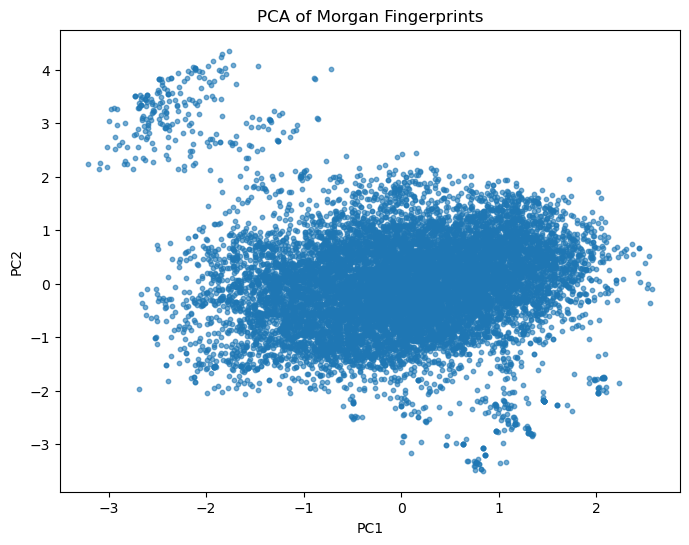

In [8]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    s=10,
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Morgan Fingerprints")

plt.show()

Middle large cloud:
✔ Most molecules share related structural patterns
✔ Main chemical space of dataset
separated molecular cluster :
-structurally different scaffold family
-unique chemistry region
3️⃣ Outliers
Few isolated points:
bottom region
edges
👉 Possible: ✔ rare chemotypes
✔ unusual scaffolds
✔ extreme structures
4️⃣ Dataset diversity
Plot is: ✔ broad ✔ spread out
Meaning:
Plain text
good structural diversity

## PCA Interpretation

The PCA plot visualizes the global chemical space of the dataset based on Morgan fingerprints.

Distinct clusters and outlier regions suggest the presence of structurally diverse molecular scaffolds within the permeability dataset.

## Uniform Manifold Approximation and Projection (UMAP)

UMAP is used to visualize local molecular neighborhoods and nonlinear chemical space structures.

Compared to PCA, UMAP often reveals molecular clusters and scaffold relationships more clearly.

In [9]:
import umap

In [10]:
umap_model = umap.UMAP(
    n_components=2,
    random_state=42
)

X_umap = umap_model.fit_transform(X)

print(X_umap.shape)

(12290, 2)


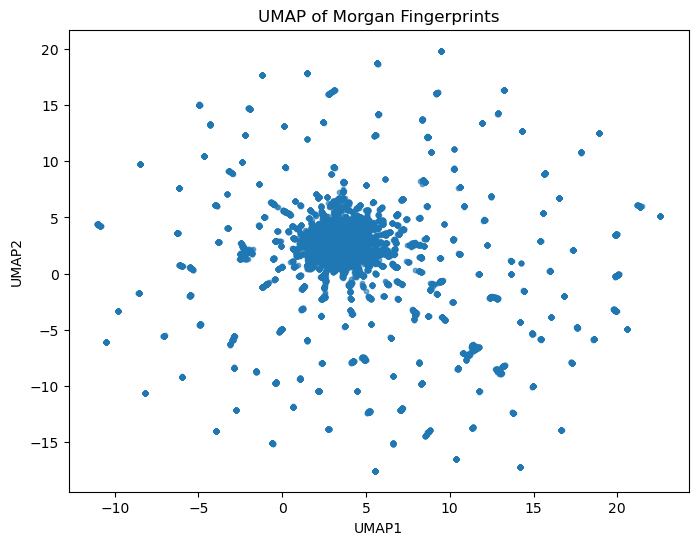

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    s=10,
    alpha=0.6
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP of Morgan Fingerprints")

plt.show()

1️⃣ Dense central cluster
Middle dense region:
✔️ many structurally related molecules
✔️ dominant scaffold space
🎯 2️⃣ Multiple isolated regions
Scattered small groups around plot:
✔️ distinct chemotypes
✔️ structurally unique molecular families
UMAP shows these MUCH better than PCA.
🎯 3️⃣ Strong dataset diversity
Your dataset is: ✔️ not collapsed into one region
✔️ chemically diverse
Very good sign for QSAR robustness.
🎯 4️⃣ Outlier molecules clearly visible
Far isolated points:
Possible:
unusual scaffolds
rare fragments
unique topology
experimental edge cases

## Permeability Region Mapping

The UMAP projection is colored using log-transformed permeability values to investigate how permeability properties are distributed across chemical space.

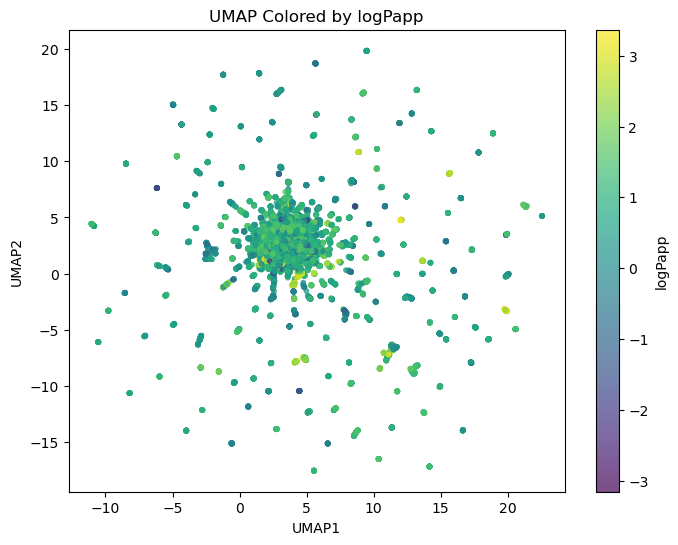

In [12]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=df['log_papp'],
    cmap='viridis',
    s=10,
    alpha=0.7
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP Colored by logPapp")

plt.colorbar(scatter, label='logPapp')

plt.show()

## Cluster Analysis

Clustering is performed on the molecular fingerprint space to identify structurally related molecular groups and chemical neighborhoods within the dataset.

In [13]:
from sklearn.cluster import KMeans
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

clusters = kmeans.fit_predict(X)

In [14]:
df['cluster'] = clusters

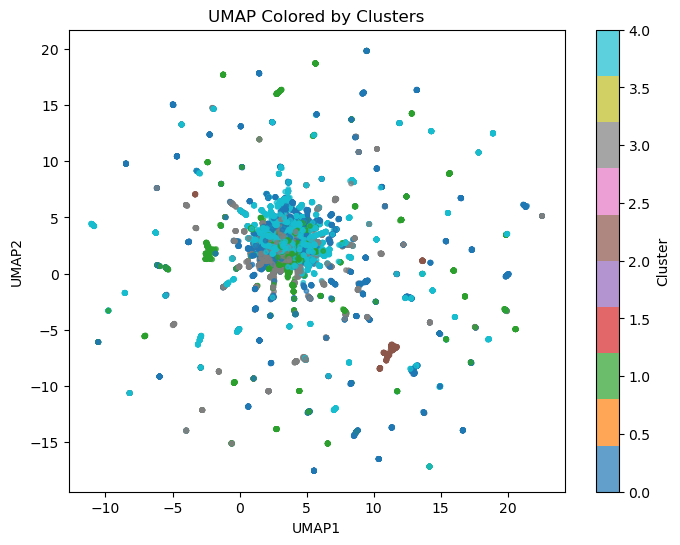

In [15]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=df['cluster'],
    cmap='tab10',
    s=10,
    alpha=0.7
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP Colored by Clusters")

plt.colorbar(scatter, label='Cluster')

plt.show()

## Cluster Interpretation

The UMAP projection combined with KMeans clustering reveals multiple structurally related molecular neighborhoods within the dataset.

Several isolated clusters and outlier regions indicate the presence of chemically distinct scaffold families and diverse permeability behaviors.

## Cluster Interpretation

The UMAP projection combined with KMeans clustering reveals multiple structurally related molecular neighborhoods within the dataset.

Several isolated clusters and outlier regions indicate the presence of chemically distinct scaffold families and diverse permeability behaviors.

In [17]:
cluster_stats = df.groupby('cluster')['log_papp'].mean()

print(cluster_stats)

cluster
0    0.810355
1    0.697758
2    1.294322
3    0.866430
4    0.894326
Name: log_papp, dtype: float64


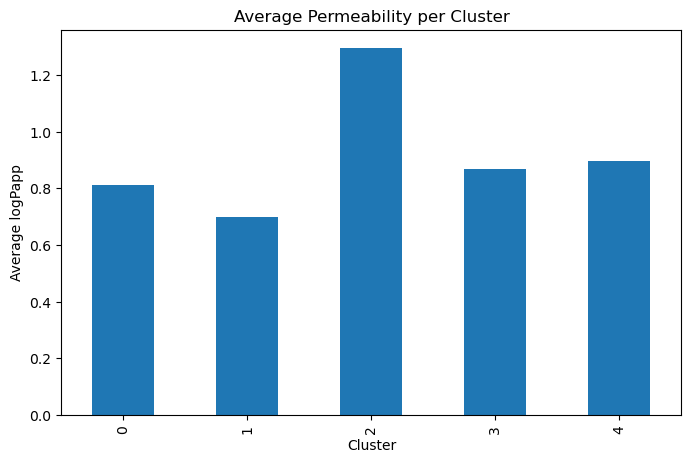

In [18]:
cluster_stats.plot(
    kind='bar',
    figsize=(8,5)
)

plt.xlabel("Cluster")
plt.ylabel("Average logPapp")
plt.title("Average Permeability per Cluster")

plt.show()

## Outlier Molecule Analysis

Outlier molecules located in isolated regions of chemical space may represent rare chemotypes or compounds with unusual permeability behavior.

In [19]:
outliers = df[
    (X_umap[:,0] > 15) |
    (X_umap[:,0] < -8) |
    (X_umap[:,1] > 15) |
    (X_umap[:,1] < -15)
]

outliers[
    ['canonical_smiles', 'log_papp', 'cluster']
].head(10)

,canonical_smiles,log_papp,cluster
142,C=C(/C=C/c1ccc([N+](=O)[O-])cc1)[C@@H]1CC[C@]2...,-0.158015,1
143,C=C(/C=C/c1cccc(Cl)c1)[C@@H]1CC[C@]2(C(=O)O)CC...,1.299507,1
144,C=C(C)C(=O)N1CCC(CN(C2Cc3cc(C#N)ccc3N(Cc3cncn3...,-0.301030,1
150,C=C(C)[C@@H]1CC[C@]2(C(=O)O)CC[C@]3(C)[C@H](CC...,-1.154902,1
151,C=C(C)[C@@H]1CC[C@]2(C(=O)O)CC[C@]3(C)[C@H](CC...,0.474216,1
152,C=C(C)[C@@H]1CC[C@]2(C(=O)O)CC[C@]3(C)[C@H](CC...,-0.049879,1
153,C=C(C)[C@@H]1CC[C@]2(C(=O)O)CC[C@]3(C)[C@H](CC...,0.746634,1
154,C=C(C)[C@@H]1CC[C@]2(C(=O)O)CC[C@]3(C)[C@H](CC...,-1.045757,1
155,C=C(C)[C@@H]1CC[C@]2(C(=O)O)CC[C@]3(C)[C@H](CC...,0.490661,0
156,C=C(C)[C@@H]1CC[C@]2(C(=O)O)CC[C@]3(C)[C@H](CC...,-0.677781,0


## Diversity Analysis

The spread of molecules across PCA and UMAP space indicates the structural diversity of the permeability dataset.

Broadly distributed molecular regions suggest the presence of multiple scaffold families and chemically diverse compounds.

In [20]:
from scipy.spatial.distance import pdist

distances = pdist(X[:1000], metric='jaccard')

print("Average Jaccard Distance:", distances.mean())

Average Jaccard Distance: 0.875343035844994


## Diversity Interpretation

The dataset shows high structural diversity with an average Jaccard distance of approximately 0.87.

This indicates that the molecular library spans broad chemical space with multiple distinct scaffold families and limited structural redundancy.

High chemical diversity is beneficial for robust QSAR modeling and generalizable machine learning performance.

# Final TDA Conclusions

This study performed Topological Data Analysis (TDA) on a curated Papp permeability dataset using Morgan molecular fingerprints and dimensionality reduction techniques.

## Key Findings

### 1. Structural Diversity
The dataset demonstrated high chemical diversity with an average Jaccard distance of approximately 0.87, indicating broad coverage of chemical space and the presence of multiple scaffold families.

### 2. PCA Analysis
Principal Component Analysis (PCA) revealed the overall global structure of the molecular dataset and identified major molecular regions along with isolated outlier compounds.

### 3. UMAP Chemical Space Visualization
UMAP provided a more detailed nonlinear representation of molecular neighborhoods and scaffold relationships. Multiple distinct molecular regions and isolated chemotypes were observed.

### 4. Permeability Distribution
Color mapping of log-transformed permeability values across UMAP space showed that permeability behavior is distributed across multiple chemical regions rather than being restricted to a single scaffold family.

### 5. Cluster Analysis
KMeans clustering identified structurally related molecular neighborhoods within the dataset. Cluster-wise permeability analysis revealed that certain molecular clusters exhibited higher average permeability values, suggesting possible topology-property relationships.

### 6. Outlier Molecules
Several isolated molecules were identified in peripheral regions of chemical space. These compounds may represent rare chemotypes, unusual structural motifs, or unique permeability behaviors.

## Overall Conclusion

The TDA workflow successfully captured the structural organization, chemical diversity, molecular clustering, and permeability-related topology of the Papp dataset.

The results demonstrate that molecular fingerprints combined with PCA, UMAP, clustering, and diversity analysis provide powerful tools for understanding chemical space and permeability behavior in cheminformatics datasets.

This analysis establishes a strong foundation for future QSAR modeling, molecular property prediction, and advanced machine learning applications.